# Оптимізація інвестиційного портфеля за допомогою PyTorch

Цей ноутбук присвячений розробці системи на основі градієнтного спуску для пошуку оптимальних ваг активів у портфелі. Мета — максимізувати **коефіцієнт Шарпа** (відношення прибутку до ризику), використовуючи автоматичне диференціювання PyTorch.

**Активи в аналізі:** Apple (AAPL), Disney (DIS), Gold Miners (GDX), Alphabet (GOOGL), Microsoft (MSFT), Netflix (NFLX), Visa (V).

In [29]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

In [30]:
def get_statistics(dfs):
    returns = {}
    profitability = {}

    for asset, data in dfs.items():
        returns[asset] = data['Close'].pct_change()
        profitability[asset] = returns[asset].mean()* 252

    returns =pd.DataFrame(returns)
    returns = returns.iloc[1:]
    returns_cov = returns.cov()

    return profitability, returns, returns_cov*252

In [39]:
def cumulative_returns(returns, allocation, name="Графік кумулятивного прибутку", custom_lable = "Оптимізований портфель"):

    weights_series = pd.Series(allocation, index=returns.columns)
    portfolio_return = returns.dot(pd.Series(weights_series))
    cumulative_returns = (1 + portfolio_return).cumprod()

    plt.figure(figsize=(12, 6))
    plt.plot(cumulative_returns, label=custom_lable, color='green', linewidth=2)
    plt.axhline(1.0, color='black', linestyle='--', alpha=0.5)

    plt.title(name, fontsize=14)
    plt.xlabel('Дата')
    plt.ylabel('Множник капіталу (1.0 = Початкова сума)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)

    final_value = cumulative_returns.iloc[-1]
    plt.annotate(f'Фінальний результат: {final_value:.2f}x',
                 xy=(cumulative_returns.index[-1], final_value),
                 xytext=(-150, 20), textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='black'))

    plt.show()

In [32]:
DATE_START = "2024-01-01"
DATE_END = pd.Timestamp.now('UTC')

apple = yf.Ticker("AAPL")
disney = yf.Ticker("DIS")
gold_miners = yf.Ticker("GDX")
alphabet = yf.Ticker("GOOGL")
microsoft = yf.Ticker("MSFT")
netflix = yf.Ticker("NFLX")
visa = yf.Ticker("V")

apple_df = apple.history(start = DATE_START, end = DATE_END)
disney_df = disney.history(start = DATE_START, end = DATE_END)
gold_miners_df = gold_miners.history(start = DATE_START, end = DATE_END)
alphabet_df = alphabet.history(start = DATE_START, end = DATE_END)
microsoft_df = microsoft.history(start = DATE_START, end = DATE_END)
netflix_df = netflix.history(start = DATE_START, end = DATE_END)
visa_df = visa.history(start = DATE_START, end = DATE_END)

assets = {
    "AAPL": apple_df,
    "DIS": disney_df,
    "GDX": gold_miners_df,
    "GOOGL": alphabet_df,
    "MSFT": microsoft_df,
    "NFLX": netflix_df,
    "V": visa_df
}

D:\MyProjects\LLMFromScratch\.venv\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
D:\MyProjects\LLMFromScratch\.venv\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
D:\MyProjects\LLMFromScratch\.venv\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
D:\MyProjects\LLMFromScratch\.venv\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
D:\MyProjects\LLMFromScratch\.ve

In [33]:
profitability, returns, returns_cov = get_statistics(assets)
profitability = torch.tensor(list(profitability.values()), dtype=float)
returns_cov = torch.tensor(returns_cov.values, dtype=float)

Epoch [0/100], Loss: 1.5872
Epoch [100/100], Loss: 2.2412
Epoch [200/100], Loss: 2.3202
Epoch [300/100], Loss: 2.3391
Epoch [400/100], Loss: 2.3471

Final Allocation: {'AAPL': np.float32(0.018225241), 'DIS': np.float32(0.03281059), 'GDX': np.float32(0.436847), 'GOOGL': np.float32(0.33610526), 'MSFT': np.float32(0.018498324), 'NFLX': np.float32(0.12254899), 'V': np.float32(0.034964625)}


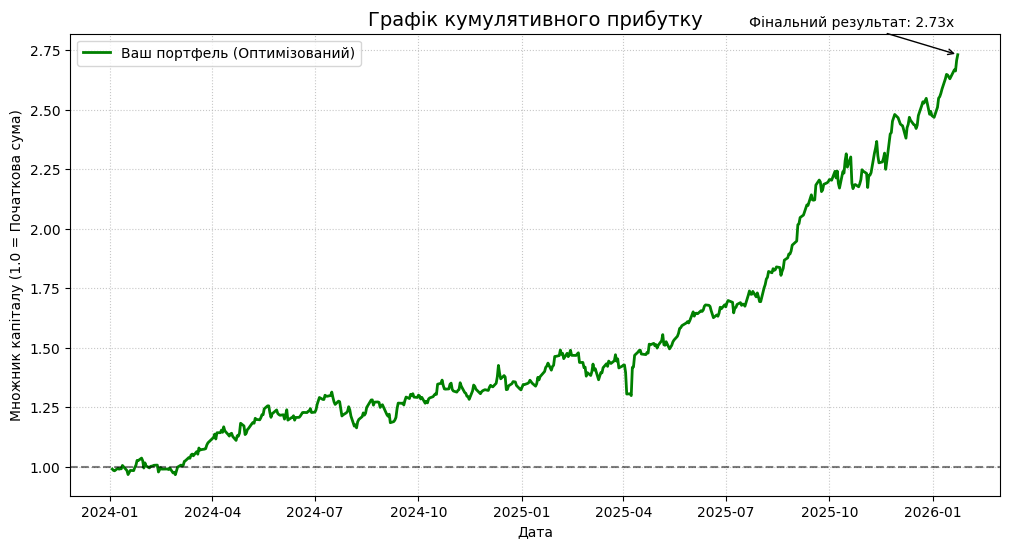

In [34]:
w = torch.rand(len(assets), requires_grad=True)
opt = torch.optim.Adam(params = [w], lr = 0.01)

for epoch in range(500):
    normal_w = torch.nn.functional.softmax(w, dim=0, dtype=float)
    expected = normal_w @ profitability
    risk = torch.sqrt(normal_w @ returns_cov @ normal_w)

    sharpe = -expected/risk

    opt.zero_grad()
    sharpe.backward()
    opt.step()

    if epoch % 100 == 0:
        print(f'Epoch [{epoch}/100], Loss: {-sharpe.item():.4f}')

final_weights = torch.nn.functional.softmax(w, dim=0).detach().numpy()
print("\nFinal Allocation:", dict(zip(assets.keys(), final_weights)))
cumulative_returns(returns, final_weights)

Після навчання моделі протягом 500 епох, ми отримали розподіл активів, який мінімізує помилку та максимізує очікувану ефективність.
Маючи задані акції ми змогли максимально оптимізувати розподіл активів використовуючи PyTorch з градієнтним спуском та навчаееям протягом 500 епох. Ефективність навчання можна побачити на графіку **Графік кумулятивного прибудку**

    Для наглядності нижче графік цього ж портфелю без оптимізації (інвестуємо рівну кількість грошей в кожну акцію)

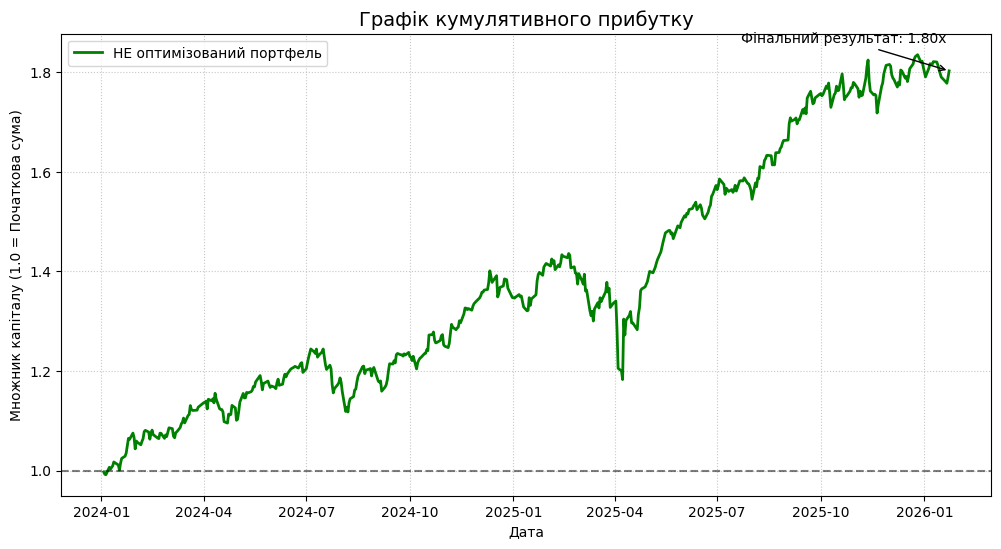

In [40]:
cumulative_returns(returns, np.zeros(len(assets))+1/len(assets), custom_lable="НЕ оптимізований портфель")